<a href="https://colab.research.google.com/github/anshukumar5431/sales/blob/main/Store_Sales_Time_Series_Forecasting_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Upload kaggle.json
# ============================================================
from google.colab import files
files.upload()  # select your kaggle.json file when prompted


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anshukumarsin","key":"c580b3f680f331798ca996fd765ba818"}'}

In [2]:
# ============================================================
# CELL 2 — Setup Kaggle API
# ============================================================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API ready")


Kaggle API ready


In [3]:
# ============================================================
# CELL 3 — Download + Unzip Dataset
# ============================================================
!kaggle competitions download -c store-sales-time-series-forecasting
!unzip -q store-sales-time-series-forecasting.zip
print("Files extracted")


100% 21.4M/21.4M [00:00<00:00, 79.6MB/s]

Files extracted


In [4]:
# CELL 4 — Load All CSV Files

import pandas as pd

train        = pd.read_csv("train.csv",            parse_dates=["date"])
test_raw     = pd.read_csv("test.csv",              parse_dates=["date"])
stores       = pd.read_csv("stores.csv")
holidays     = pd.read_csv("holidays_events.csv",  parse_dates=["date"])
oil          = pd.read_csv("oil.csv",              parse_dates=["date"])
transactions = pd.read_csv("transactions.csv",     parse_dates=["date"])

print("All files loaded")


All files loaded


In [5]:

print("=== SHAPE ===")
print("train        :", train.shape)
print("stores       :", stores.shape)
print("holidays     :", holidays.shape)
print("oil          :", oil.shape)
print("transactions :", transactions.shape)


=== SHAPE ===
train        : (3000888, 6)
stores       : (54, 5)
holidays     : (350, 6)
oil          : (1218, 2)
transactions : (83488, 3)


In [6]:
print(train.head())

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


In [7]:
print(stores.head())

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


In [8]:
print(holidays.head())

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  


In [9]:
print(oil.head())

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20


In [10]:
print(transactions.head())

        date  store_nbr  transactions
0 2013-01-01         25           770
1 2013-01-02          1          2111
2 2013-01-02          2          2358
3 2013-01-02          3          3487
4 2013-01-02          4          1922


In [11]:
# merge stores info
df = train.merge(stores, on="store_nbr", how="left")

# merge oil price
df = df.merge(oil, on="date", how="left")

# merge transactions
df = df.merge(transactions, on=["date", "store_nbr"], how="left")

# we have only taken date and type from holiday and left evrything
hol = holidays[["date", "type"]].rename(columns={"type": "holiday_type"})
df = df.merge(hol, on="date", how="left")

print("Duplicates before dedup:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after dedup :", df.duplicated().sum())


Duplicates before dedup: 30294
Duplicates after dedup : 0


In [12]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  dcoilwtico  transactions holiday_type  
0    D       13         NaN           NaN      Holiday  
1    D       13         NaN           NaN      Holiday  
2    D       13         NaN           NaN      Holiday  
3    D       13         NaN           NaN      Holiday  
4    D       13         NaN           NaN      Holiday  


In [13]:
print(df.shape)

(3024054, 13)


In [14]:
df['date'] = pd.to_datetime(df['date']) # It converts the date column from text (string) into a datetime data type that pandas understands.

In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024054 entries, 0 to 3024053
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
 12  holiday_type  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(5)
memory usage: 299.9+ MB
None


In [16]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

# 🎯 Why We Are Doing This

Models cannot understand raw dates directly.

So we convert dates into:

year
month
day
weekday

This helps model learn patterns like:

weekend sales
monthly trends
yearly seasonality

In [17]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  dcoilwtico  transactions holiday_type  year  month  day  \
0    D       13         NaN           NaN      Holiday  2013      1    1   
1    D       13         NaN           NaN      Holiday  2013      1    1   
2    D       13         NaN           NaN      Holiday  2013      1    1   
3    D       13         NaN           NaN      Holiday  2013      1    1   
4    D       13         NaN           NaN      Holiday  2013      1    1   

   day_of_week  
0            1  
1            1  
2    

In [18]:
# 1. rename column
df = df.rename(columns={
    "type"       : "store_type",
    "dcoilwtico" : "oil_price"
})


In [19]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  store_type  cluster  oil_price  transactions holiday_type  year  month  day  \
0          D       13        NaN           NaN      Holiday  2013      1    1   
1          D       13        NaN           NaN      Holiday  2013      1    1   
2          D       13        NaN           NaN      Holiday  2013      1    1   
3          D       13        NaN           NaN      Holiday  2013      1    1   
4          D       13        NaN           NaN      Holiday  2013      1    1   

   day_of_week  
0        

# Exploratory Data Analysis (EDA)

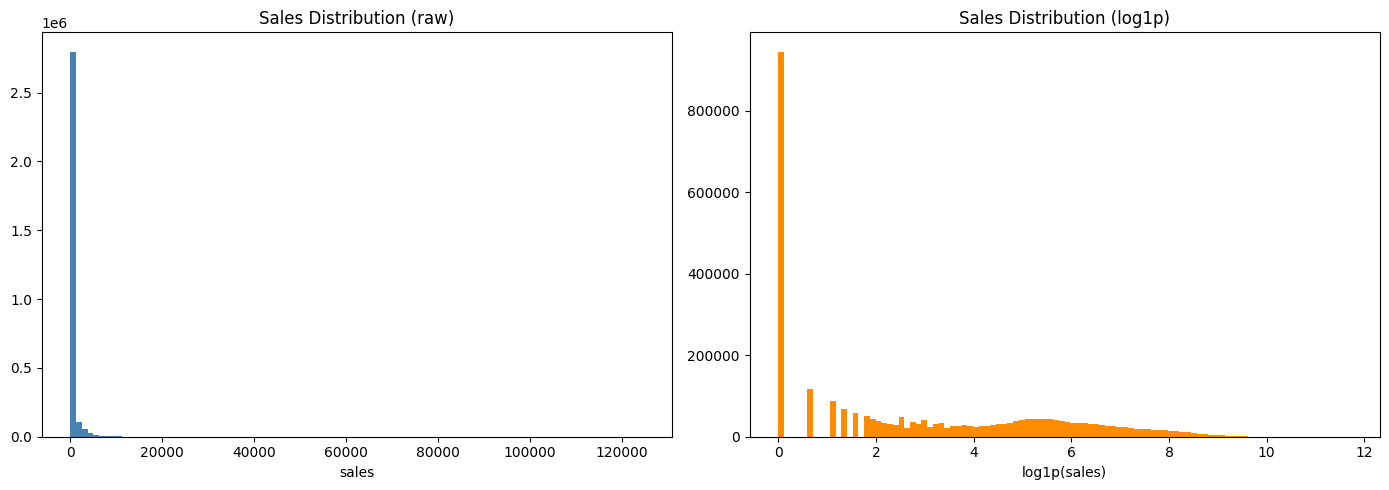

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Target distribution -- raw vs log1p (shows the right-skew)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sales'], bins=100, color='steelblue')
axes[0].set_title('Sales Distribution (raw)')
axes[0].set_xlabel('sales')

axes[1].hist(np.log1p(df['sales']), bins=100, color='darkorange')
axes[1].set_title('Sales Distribution (log1p)')
axes[1].set_xlabel('log1p(sales)')

plt.tight_layout()
plt.show()


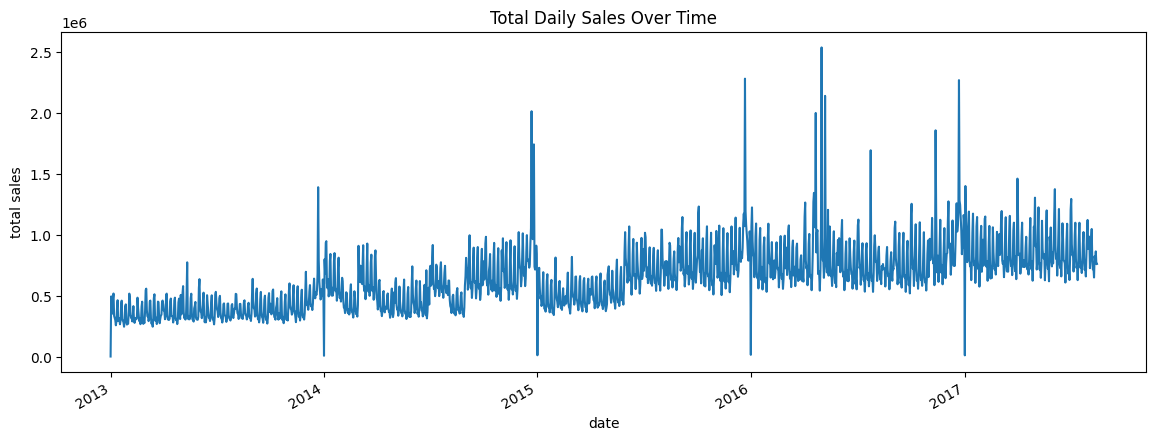

In [21]:
# 2. Sales trend over time (total daily sales across all stores/families)
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(14, 5))
daily_sales.plot()
plt.title('Total Daily Sales Over Time')
plt.xlabel('date')
plt.ylabel('total sales')
plt.show()


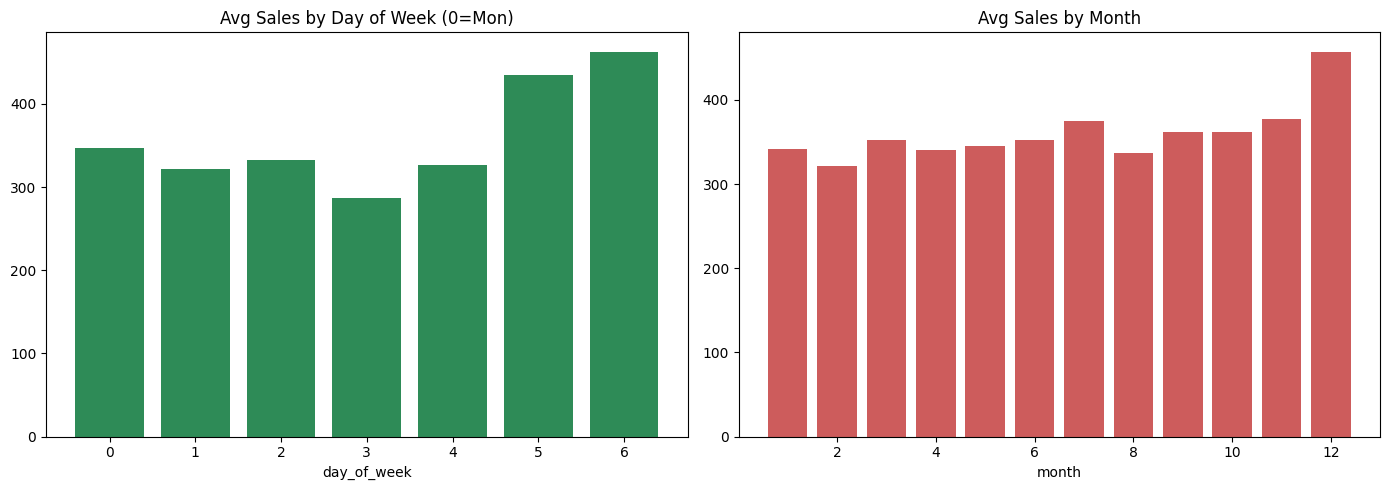

In [22]:
# 3. Seasonality -- avg sales by day of week and by month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_sales = df.groupby('day_of_week')['sales'].mean()
axes[0].bar(dow_sales.index, dow_sales.values, color='seagreen')
axes[0].set_title('Avg Sales by Day of Week (0=Mon)')
axes[0].set_xlabel('day_of_week')

month_sales = df.groupby('month')['sales'].mean()
axes[1].bar(month_sales.index, month_sales.values, color='indianred')
axes[1].set_title('Avg Sales by Month')
axes[1].set_xlabel('month')

plt.tight_layout()
plt.show()


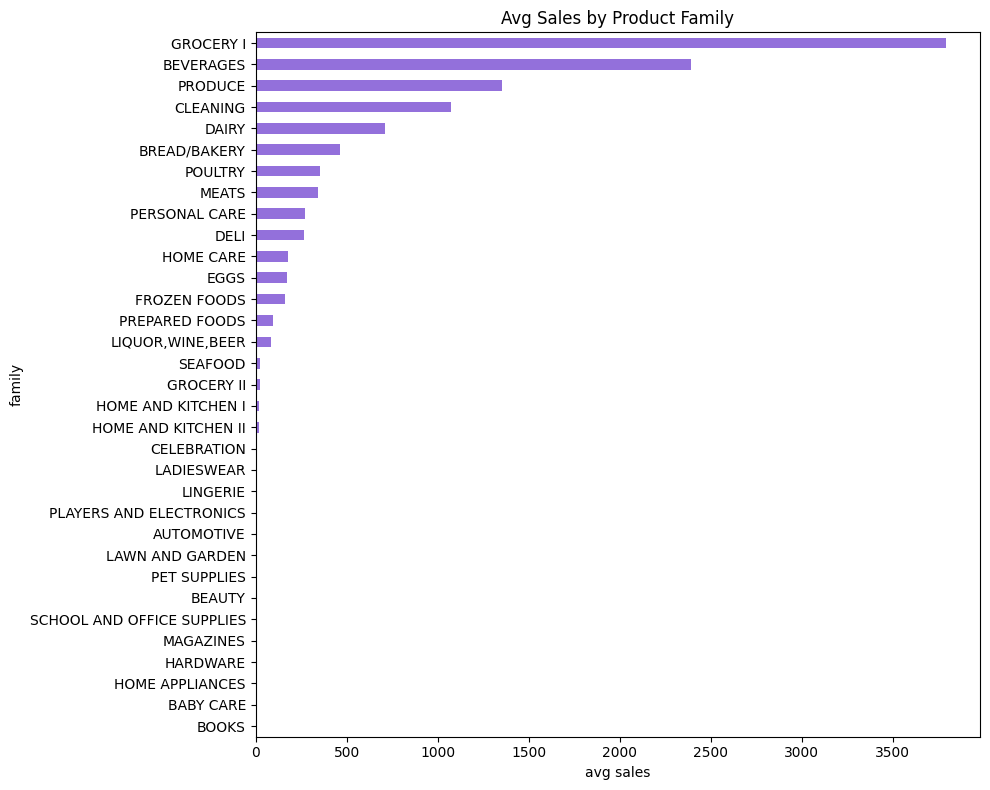

In [23]:
# 4. Sales by product family -- which categories sell the most
family_sales = df.groupby('family')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
family_sales.plot(kind='barh', color='mediumpurple')
plt.title('Avg Sales by Product Family')
plt.xlabel('avg sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


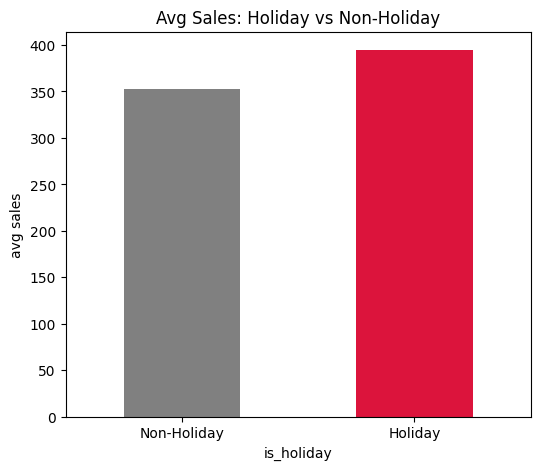

In [24]:
# 5. Holiday effect -- avg sales on holiday vs non-holiday days
df['is_holiday'] = df['holiday_type'].notna()

holiday_sales = df.groupby('is_holiday')['sales'].mean()

plt.figure(figsize=(6, 5))
holiday_sales.plot(kind='bar', color=['gray', 'crimson'])
plt.title('Avg Sales: Holiday vs Non-Holiday')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylabel('avg sales')
plt.show()


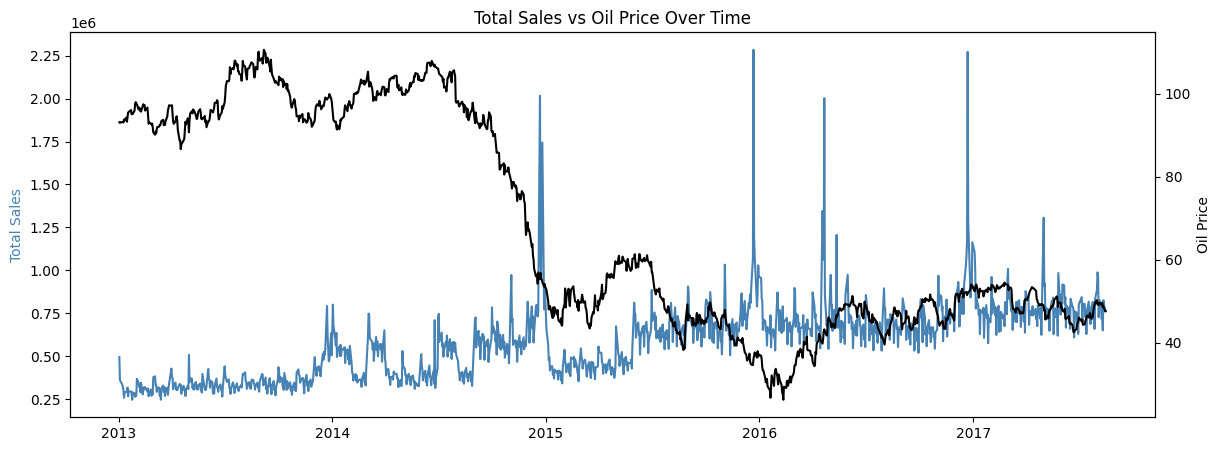

In [25]:
# 6. Oil price vs sales (Ecuador is an oil-dependent economy)
oil_sales = df.dropna(subset=['oil_price']).groupby('date').agg(
    total_sales=('sales', 'sum'),
    oil_price=('oil_price', 'mean')
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(oil_sales.index, oil_sales['total_sales'], color='steelblue', label='Total Sales')
ax1.set_ylabel('Total Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(oil_sales.index, oil_sales['oil_price'], color='black', label='Oil Price')
ax2.set_ylabel('Oil Price', color='black')

plt.title('Total Sales vs Oil Price Over Time')
plt.show()


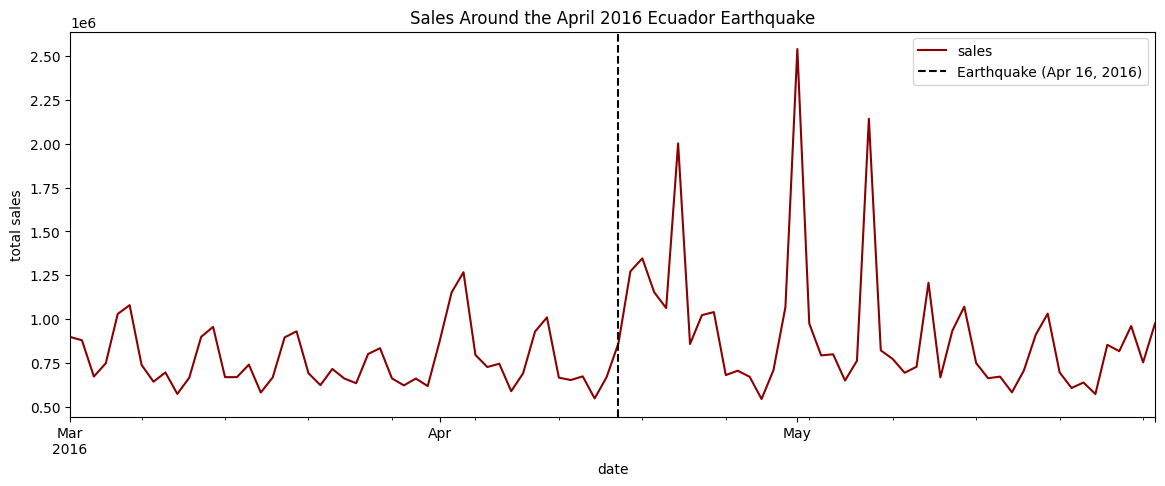

In [26]:
# 7. Earthquake impact -- zoom into April 2016 Ecuador earthquake
eq_window = df[(df['date'] >= '2016-03-01') & (df['date'] <= '2016-05-31')]
eq_daily = eq_window.groupby('date')['sales'].sum()

plt.figure(figsize=(14, 5))
eq_daily.plot(color='darkred')
plt.axvline(pd.Timestamp('2016-04-16'), color='black', linestyle='--', label='Earthquake (Apr 16, 2016)')
plt.title('Sales Around the April 2016 Ecuador Earthquake')
plt.xlabel('date')
plt.ylabel('total sales')
plt.legend()
plt.show()


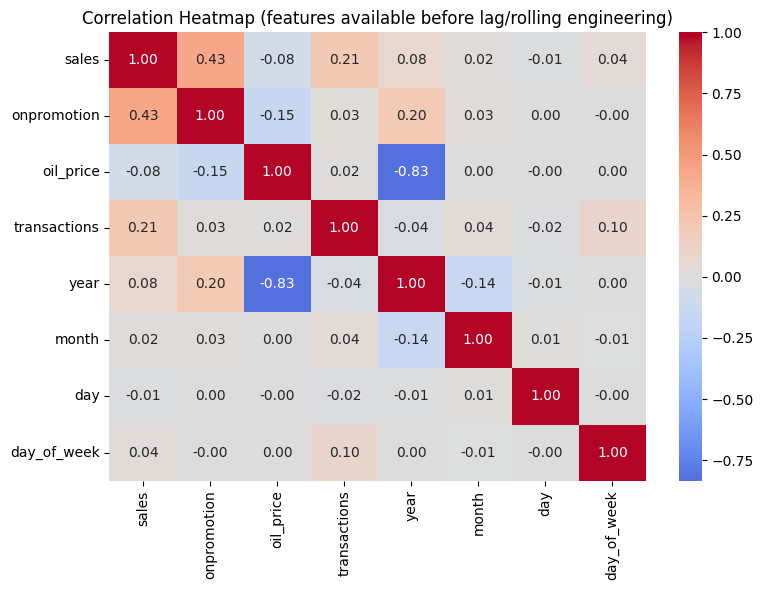

In [27]:
# 8. Correlation heatmap of numeric features available at this stage
num_cols = ['sales', 'onpromotion', 'oil_price', 'transactions', 'year', 'month', 'day', 'day_of_week']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (features available before lag/rolling engineering)')
plt.tight_layout()
plt.show()


# Feature Engineering (Lag + Rolling Features)

In [28]:

# STEP 1 — sort first (CRITICAL — never skip this)
df = df.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

# STEP 2 — LAG FEATURES (we are calculating the sales exactly x days ago)
df["lag_1"]   = df.groupby(["store_nbr", "family"])["sales"].shift(1)
df["lag_7"]   = df.groupby(["store_nbr", "family"])["sales"].shift(7)
df["lag_14"]  = df.groupby(["store_nbr", "family"])["sales"].shift(14)
df["lag_30"]  = df.groupby(["store_nbr", "family"])["sales"].shift(30)
df["lag_365"] = df.groupby(["store_nbr", "family"])["sales"].shift(365)

# STEP 3 — ROLLING FEATURES (mean of that perticular range )
df["rolling_mean_7"]  = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).mean())

df["rolling_mean_30"] = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(30).mean())

df["rolling_std_7"]   = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).std())

# STEP 4 — DROP rows where lag values are NaN
# (first 365 rows per store+family will have NaN — remove them)
df = df.dropna(subset=["lag_1", "lag_7", "lag_14",
                        "lag_30", "lag_365",
                        "rolling_mean_7", "rolling_mean_30",
                        "rolling_std_7"])

df = df.reset_index(drop=True)

# STEP 5 — VERIFY
print("Shape after feature engineering:", df.shape)
print("\nNull counts:\n", df.isnull().sum())
print("\nSample:")
print(df[["date", "store_nbr", "family", "sales",
          "lag_1", "lag_7", "rolling_mean_7",
          "rolling_std_7"]].head(10))

Shape after feature engineering: (2373624, 26)

Null counts:
 id                       0
date                     0
store_nbr                0
family                   0
sales                    0
onpromotion              0
city                     0
state                    0
store_type               0
cluster                  0
oil_price           735966
transactions        156255
holiday_type       1983366
year                     0
month                    0
day                      0
day_of_week              0
is_holiday               0
lag_1                    0
lag_7                    0
lag_14                   0
lag_30                   0
lag_365                  0
rolling_mean_7           0
rolling_mean_30          0
rolling_std_7            0
dtype: int64

Sample:
        date  store_nbr      family  sales  lag_1  lag_7  rolling_mean_7  \
0 2013-12-31          1  AUTOMOTIVE    2.0    1.0    1.0        2.142857   
1 2014-01-01          1  AUTOMOTIVE    0.0    2.0    1.0      

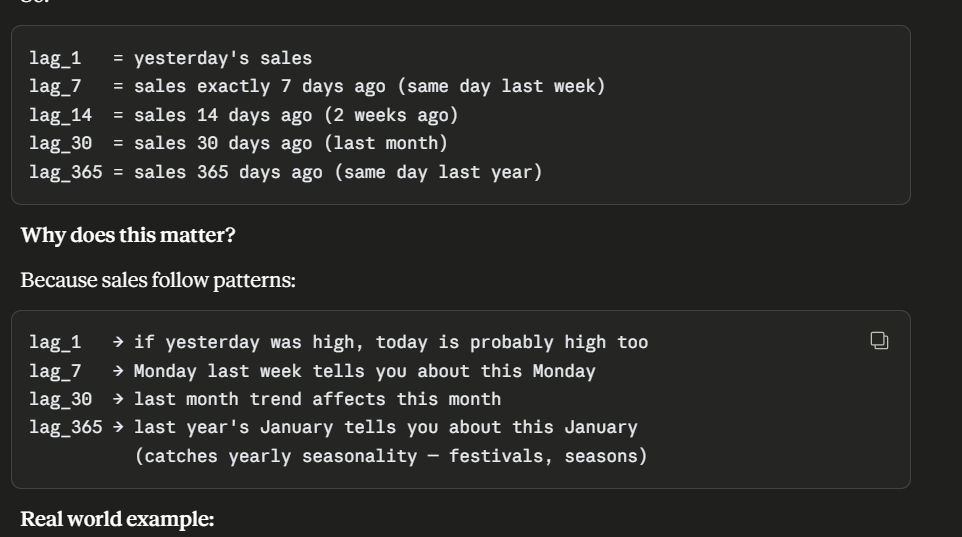

In [29]:
print(df.head())


       id       date  store_nbr      family  sales  onpromotion   city  \
0  646866 2013-12-31          1  AUTOMOTIVE    2.0            0  Quito   
1  648648 2014-01-01          1  AUTOMOTIVE    0.0            0  Quito   
2  650430 2014-01-02          1  AUTOMOTIVE    3.0            0  Quito   
3  652212 2014-01-03          1  AUTOMOTIVE    0.0            0  Quito   
4  653994 2014-01-04          1  AUTOMOTIVE    0.0            0  Quito   

       state store_type  cluster  ...  day_of_week  is_holiday lag_1  lag_7  \
0  Pichincha          D       13  ...            1        True   1.0    1.0   
1  Pichincha          D       13  ...            2        True   2.0    1.0   
2  Pichincha          D       13  ...            3       False   0.0    2.0   
3  Pichincha          D       13  ...            4       False   3.0    6.0   
4  Pichincha          D       13  ...            5       False   0.0    4.0   

   lag_14  lag_30  lag_365  rolling_mean_7  rolling_mean_30  rolling_std_7  
0  

In [30]:
print(df.isnull().sum())

id                       0
date                     0
store_nbr                0
family                   0
sales                    0
onpromotion              0
city                     0
state                    0
store_type               0
cluster                  0
oil_price           735966
transactions        156255
holiday_type       1983366
year                     0
month                    0
day                      0
day_of_week              0
is_holiday               0
lag_1                    0
lag_7                    0
lag_14                   0
lag_30                   0
lag_365                  0
rolling_mean_7           0
rolling_mean_30          0
rolling_std_7            0
dtype: int64


In [31]:
df['oil_price'] = df['oil_price'].fillna(method='ffill')

/tmp/ipykernel_24135/3810549490.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['oil_price'] = df['oil_price'].fillna(method='ffill')


In [32]:
df['transactions'] = df['transactions'].fillna(df['transactions'].median())

In [33]:
df['holiday_type'] = df['holiday_type'].fillna('None')

In [34]:
print(df.isnull().sum())

id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        0
city               0
state              0
store_type         0
cluster            0
oil_price          0
transactions       0
holiday_type       0
year               0
month              0
day                0
day_of_week        0
is_holiday         0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
lag_365            0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
dtype: int64


In [35]:
print("Duplicate check (should already be 0 — deduped at merge step):")
print(df.duplicated().sum())


Duplicate check (should already be 0 — deduped at merge step):
0


In [36]:
duplicates = df[df.duplicated()]
print(duplicates.head())


Empty DataFrame
Columns: [id, date, store_nbr, family, sales, onpromotion, city, state, store_type, cluster, oil_price, transactions, holiday_type, year, month, day, day_of_week, is_holiday, lag_1, lag_7, lag_14, lag_30, lag_365, rolling_mean_7, rolling_mean_30, rolling_std_7]
Index: []

[0 rows x 26 columns]


In [38]:
print(df.duplicated().sum())


0


In [39]:
print(df.select_dtypes(include='object').columns)

Index(['family', 'city', 'state', 'store_type', 'holiday_type'], dtype='object')


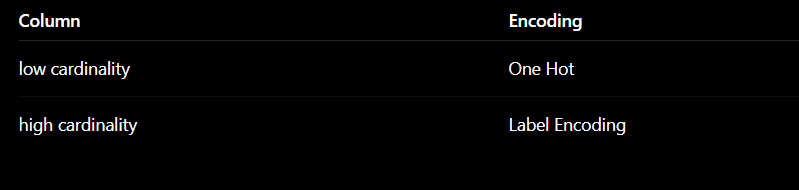

In [40]:
for col in ['family', 'city', 'state', 'store_type', 'holiday_type']:
    print(col, ":", df[col].nunique())

family : 33
city : 22
state : 16
store_type : 5
holiday_type : 7


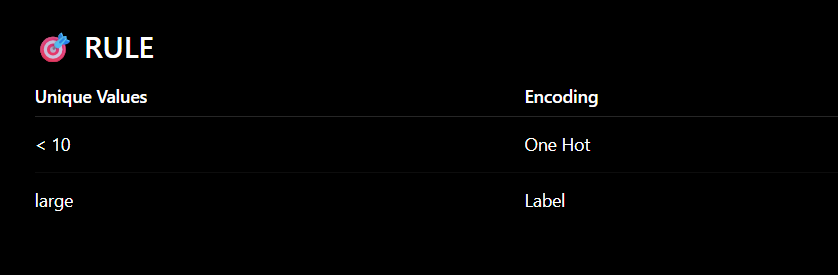

In [41]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['family', 'city', 'state']

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

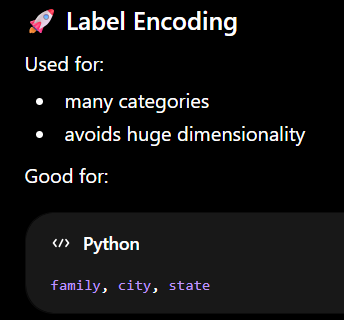

In [42]:
df = pd.get_dummies(
    df,
    columns=['store_type', 'holiday_type'],
    drop_first=True
)

In [43]:
print(df.head())

       id       date  store_nbr  family  sales  onpromotion  city  state  \
0  646866 2013-12-31          1       0    2.0            0    18     12   
1  648648 2014-01-01          1       0    0.0            0    18     12   
2  650430 2014-01-02          1       0    3.0            0    18     12   
3  652212 2014-01-03          1       0    0.0            0    18     12   
4  653994 2014-01-04          1       0    0.0            0    18     12   

   cluster  oil_price  ...  store_type_B  store_type_C  store_type_D  \
0       13      98.17  ...         False         False          True   
1       13      98.17  ...         False         False          True   
2       13      95.14  ...         False         False          True   
3       13      93.66  ...         False         False          True   
4       13      93.66  ...         False         False          True   

   store_type_E  holiday_type_Bridge  holiday_type_Event  \
0         False                False              

In [44]:
print(df.shape)

(2373624, 34)


In [45]:
print(df['oil_price'].isnull().sum())

0


In [46]:
df['oil_price'] = df['oil_price'].ffill()
df['oil_price'] = df['oil_price'].bfill()

In [47]:
print(df.head())

       id       date  store_nbr  family  sales  onpromotion  city  state  \
0  646866 2013-12-31          1       0    2.0            0    18     12   
1  648648 2014-01-01          1       0    0.0            0    18     12   
2  650430 2014-01-02          1       0    3.0            0    18     12   
3  652212 2014-01-03          1       0    0.0            0    18     12   
4  653994 2014-01-04          1       0    0.0            0    18     12   

   cluster  oil_price  ...  store_type_B  store_type_C  store_type_D  \
0       13      98.17  ...         False         False          True   
1       13      98.17  ...         False         False          True   
2       13      95.14  ...         False         False          True   
3       13      93.66  ...         False         False          True   
4       13      93.66  ...         False         False          True   

   store_type_E  holiday_type_Bridge  holiday_type_Event  \
0         False                False              

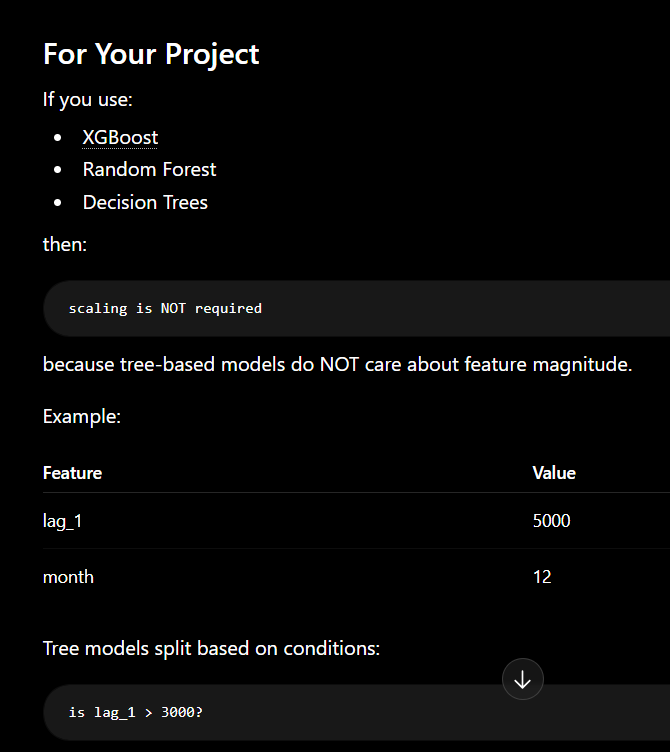

In [48]:
# STEP 1: Check date range
print(df['date'].min())  # When does data start?
print(df['date'].max())  # When does data end?

# STEP 2: Auto-calculate split date as ~80-20 based on the actual data range,
# instead of a hardcoded date. This adapts automatically if the dataset
# changes (different download, more/less history, etc.).
date_range_days = (df['date'].max() - df['date'].min()).days
split_date = df['date'].min() + pd.Timedelta(days=int(date_range_days * 0.8))
print(f"Auto-calculated split date: {split_date.date()}")

train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

# STEP 3: Separate features (X) from target (y)
X_train = train_df.drop(['date', 'sales'], axis=1)
y_train = train_df['sales']

X_test = test_df.drop(['date', 'sales'], axis=1)
y_test = test_df['sales']

# STEP 4: Verify shapes
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Date ranges - Train: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Date ranges - Test:  {test_df['date'].min()} to {test_df['date'].max()}")


2013-12-31 00:00:00
2017-08-15 00:00:00
Auto-calculated split date: 2016-11-23
Train: (1899612, 32), Test: (474012, 32)
Date ranges - Train: 2013-12-31 00:00:00 to 2016-11-22 00:00:00
Date ranges - Test:  2016-11-23 00:00:00 to 2017-08-15 00:00:00


# Time-Series Cross-Validation

A single fixed date split only tests the model on one time window. `TimeSeriesSplit` instead trains/tests across several rolling windows (train window grows, test window always moves forward in time -- never shuffled, so no future data leaks into the past) to give a more reliable estimate of real performance. The final model below still uses the single date split for the actual train/test/SHAP workflow -- this section is a validation check, not a replacement.

* TimeSeriesSplit is a cross-validation technique for time-series data that estimates how reliable your model is across different time periods—it does not validate whether your train-test split is correct.

In [49]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor
import numpy as np

X_all = df.drop(['date', 'sales'], axis=1)
y_all = df['sales']

tscv = TimeSeriesSplit(n_splits=5)
fold_rmsle = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all), 1):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    cv_model = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, random_state=42)
    cv_model.fit(X_tr, np.log1p(y_tr))

    y_val_pred = np.clip(np.expm1(cv_model.predict(X_val)), 0, None)
    rmsle = np.sqrt(mean_squared_log_error(y_val, y_val_pred))
    fold_rmsle.append(rmsle)
    print(f"Fold {fold}: RMSLE = {rmsle:.4f}")

print(f"\nAverage RMSLE across {tscv.n_splits} folds: {np.mean(fold_rmsle):.4f} (+/- {np.std(fold_rmsle):.4f})")


Fold 1: RMSLE = 0.5653
Fold 2: RMSLE = 0.4481
Fold 3: RMSLE = 0.4341
Fold 4: RMSLE = 0.4635
Fold 5: RMSLE = 0.3956

Average RMSLE across 5 folds: 0.4613 (+/- 0.0567)


# Hyperparameter Tuning

Instead of hardcoded guesses (`n_estimators=200, max_depth=7, learning_rate=0.1`), search for better XGBoost parameters using `RandomizedSearchCV` with `TimeSeriesSplit` as the cross-validation strategy (so tuning also respects time order, no shuffling).

In [50]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 7, 9],
    'learning_rate': [0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    scoring='neg_root_mean_squared_error',  # scored on log1p(sales) below -> equivalent to RMSLE
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, np.log1p(y_train))

print("Best params:", search.best_params_)
print("Best CV score (RMSLE, log-space RMSE):", -search.best_score_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV score (RMSLE, log-space RMSE): 0.41382482228401196


In [51]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error
import numpy as np

# OPTION 1: Quick model (Random Forest - trains fast)
#model = RandomForestRegressor(
#    n_estimators=100,
#    max_depth=15,
#    n_jobs=-1,
#    random_state=42
#)

# OPTION 2: Better model (XGBoost - tuned via RandomizedSearchCV above,
# instead of hardcoded guesses)
model = XGBRegressor(**search.best_params_, random_state=42)

# FIX: competition metric is RMSLE and sales is heavily right-skewed,
# so train on log1p(sales) instead of raw sales, then invert with expm1.
y_train_log = np.log1p(y_train)

# Train
print("Training...")
model.fit(X_train, y_train_log)
print("✅ Training complete!")

# Predict (invert log back to real sales scale)
y_pred_train = np.expm1(model.predict(X_train))
y_pred_test = np.expm1(model.predict(X_test))

# log-space model can occasionally predict just below 0 -- sales can't be negative
y_pred_train = np.clip(y_pred_train, 0, None)
y_pred_test = np.clip(y_pred_test, 0, None)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = mean_absolute_percentage_error(y_test, y_pred_test)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"\n📊 Results:")
print(f"MAE:   ${mae:,.2f}")
print(f"RMSE:  ${rmse:,.2f}")
print(f"MAPE:  {mape:.2%}")
print(f"RMSLE: {rmsle:.4f}  (competition metric)")


Training...
✅ Training complete!

📊 Results:
MAE:   $66.62
RMSE:  $288.32
MAPE:  48305576898113112.00%
RMSLE: 0.4247  (competition metric)


# Error Analysis

The overall MAE/RMSE/RMSLE tell you *how much* error there is on average, but not *where* it's coming from. This section breaks the test-set error down by product family, by store, and over time -- so you can see which categories or stores the model struggles with, and whether the error gets worse the further out (in time) you predict.

### 1. Error by product family
Which categories does the model predict well vs badly? A high error on a high-volume family (like GROCERY) matters more than the same error on a rarely-sold one.

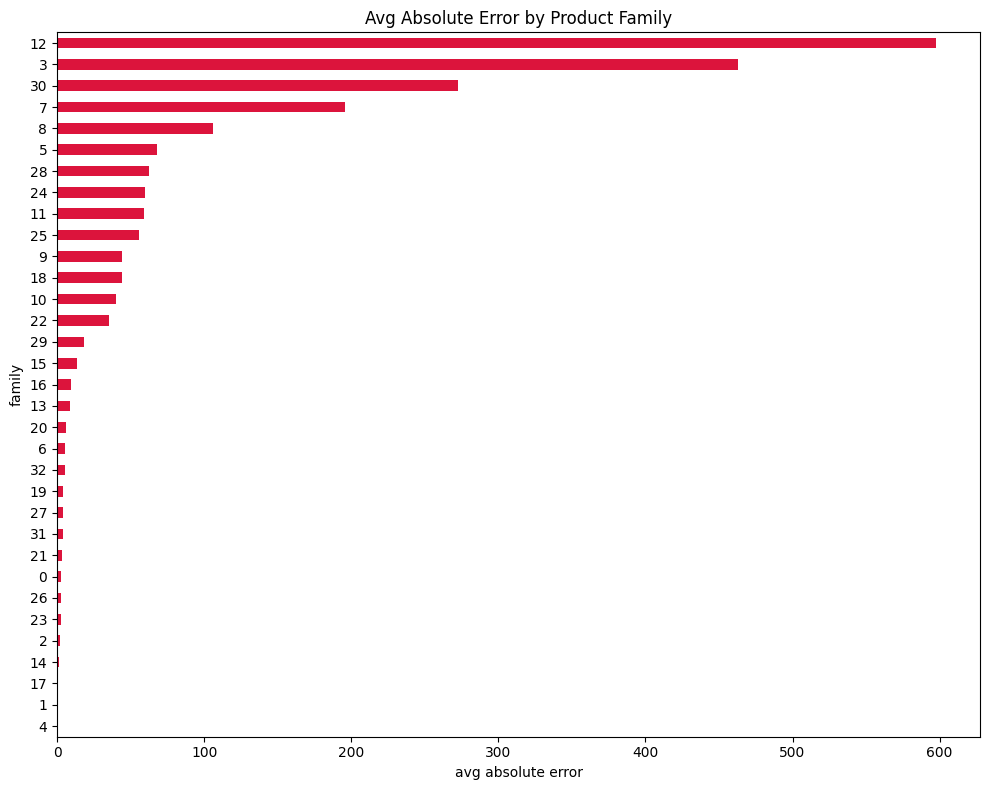

In [52]:
test_df_eval = test_df.copy()
test_df_eval['y_pred'] = y_pred_test
test_df_eval['abs_error'] = (test_df_eval['sales'] - test_df_eval['y_pred']).abs()

family_error = test_df_eval.groupby('family')['abs_error'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
family_error.plot(kind='barh', color='crimson')
plt.title('Avg Absolute Error by Product Family')
plt.xlabel('avg absolute error')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 2. Error by store
Are a handful of stores dragging the average error up? This can point to store-specific patterns (location, size, local events) the model isn't capturing.

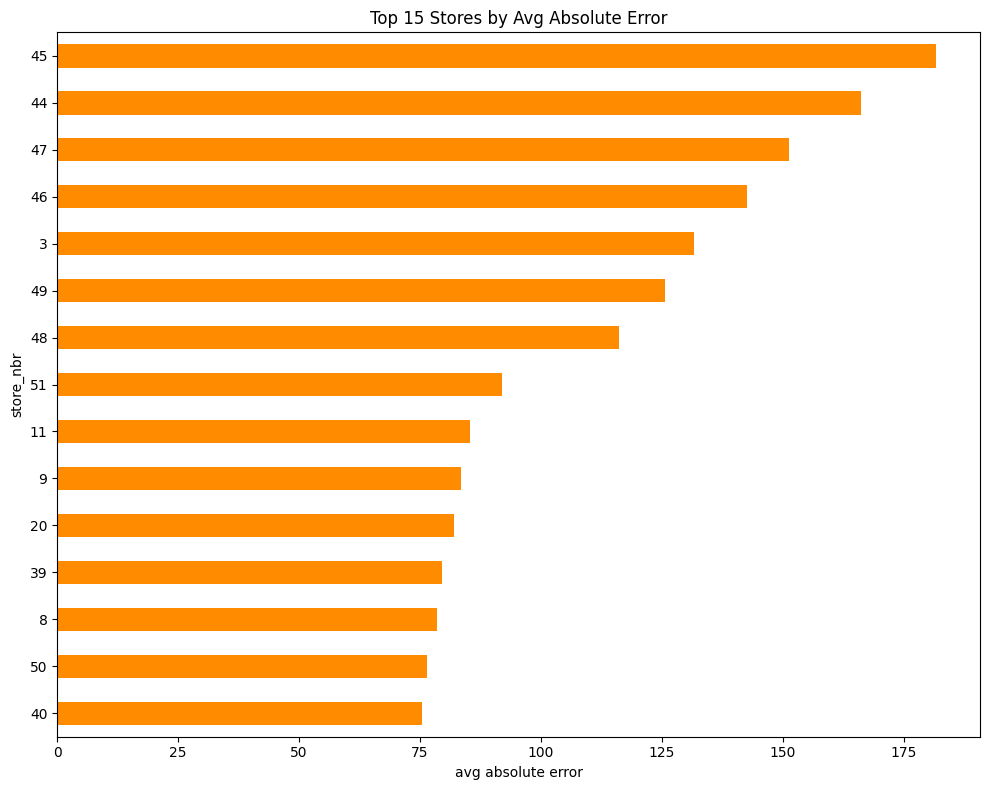

In [53]:
store_error = test_df_eval.groupby('store_nbr')['abs_error'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
store_error.head(15).plot(kind='barh', color='darkorange')
plt.title('Top 15 Stores by Avg Absolute Error')
plt.xlabel('avg absolute error')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 3. Error over time
Plotting actual vs predicted total daily sales on the test period shows whether the model stays accurate throughout, or drifts (gets worse) the further it predicts past the training cutoff.

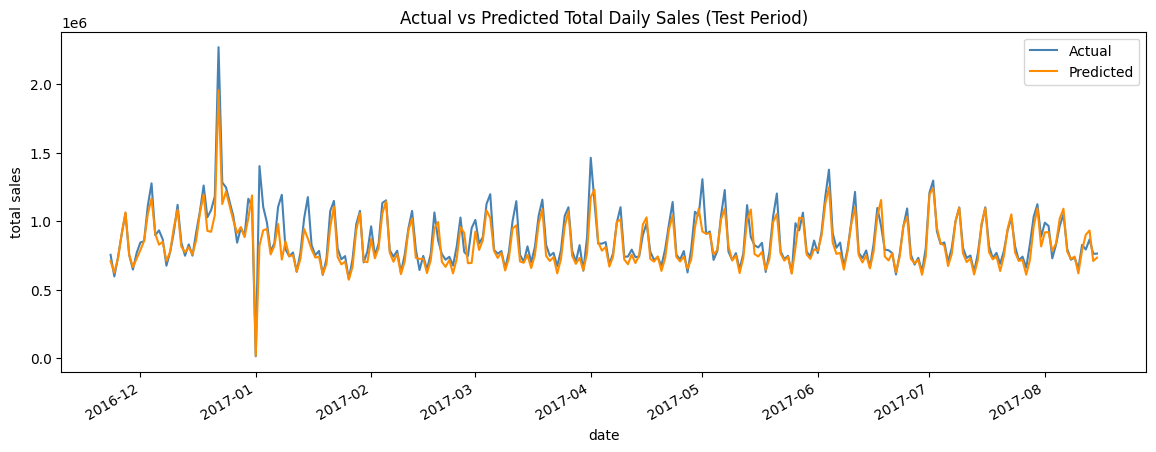

In [54]:
daily_actual = test_df_eval.groupby('date')['sales'].sum()
daily_pred = test_df_eval.groupby('date')['y_pred'].sum()

plt.figure(figsize=(14, 5))
daily_actual.plot(label='Actual', color='steelblue')
daily_pred.plot(label='Predicted', color='darkorange')
plt.title('Actual vs Predicted Total Daily Sales (Test Period)')
plt.xlabel('date')
plt.ylabel('total sales')
plt.legend()
plt.show()


# Model Explainability (SHAP)

In [ ]:
import shap

# TreeExplainer works natively and fast with XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


In [ ]:
# global feature importance -- which features matter most overall
shap.summary_plot(shap_values, X_test, plot_type='bar')


In [ ]:
# impact direction -- how each feature pushes predictions up/down
shap.summary_plot(shap_values, X_test)


* the below code if for checking how good your modele is working on real outside data given by kaggle

# Kaggle Submission Pipeline (test.csv -> submission.csv)

This is the actual competition deliverable: predict `sales` for every row in `test.csv` (Aug 16-31, 2017) and save it as `submission.csv`.

**Why this can't just reuse `df` from earlier:** `test.csv` has no `sales` column, and the lag features (`lag_7`, `lag_365`, etc.) need real historical sales values to look back on. So `train` and `test` are combined first, the same feature engineering is re-applied to the combined data, and then only the test rows are sliced back out at the end -- this way `lag_365` for an Aug 16 2017 test row correctly looks back at the real Aug 16 2016 sales from `train`.

### 2. Combine train + test, then re-run the same merges
`sales` is set to `NaN` for the test rows so they carry through the lag/rolling calculations without polluting them, and `is_test` marks which rows to slice out again at the end.

In [ ]:
train_raw = train.copy()
train_raw['is_test'] = False

test_full = test_raw.copy()
test_full['sales'] = np.nan
test_full['is_test'] = True

combined = pd.concat([train_raw, test_full], ignore_index=True, sort=False)

# same merges as the main pipeline (stores, oil, transactions, holidays)
combined = combined.merge(stores, on="store_nbr", how="left")
combined = combined.merge(oil, on="date", how="left")
combined = combined.merge(transactions, on=["date", "store_nbr"], how="left")

hol = holidays[["date", "type"]].rename(columns={"type": "holiday_type"})
combined = combined.merge(hol, on="date", how="left")

# FIX: dedupe before any lag/rolling features are computed (same rule as the main pipeline)
combined = combined.drop_duplicates().reset_index(drop=True)

combined = combined.rename(columns={"type": "store_type", "dcoilwtico": "oil_price"})

combined['date'] = pd.to_datetime(combined['date'])
combined['year'] = combined['date'].dt.year
combined['month'] = combined['date'].dt.month
combined['day'] = combined['date'].dt.day
combined['day_of_week'] = combined['date'].dt.dayofweek

print(combined.shape)


### 3. Lag/rolling features + null handling
Fill values (oil ffill/bfill, transactions median) are computed from the **train** portion only, then applied to both -- the test period has no real transactions data, so it must borrow train's statistics rather than its own.

In [ ]:
combined = combined.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

combined["lag_1"]   = combined.groupby(["store_nbr", "family"])["sales"].shift(1)
combined["lag_7"]   = combined.groupby(["store_nbr", "family"])["sales"].shift(7)
combined["lag_14"]  = combined.groupby(["store_nbr", "family"])["sales"].shift(14)
combined["lag_30"]  = combined.groupby(["store_nbr", "family"])["sales"].shift(30)
combined["lag_365"] = combined.groupby(["store_nbr", "family"])["sales"].shift(365)

combined["rolling_mean_7"]  = combined.groupby(["store_nbr", "family"])["sales"].transform(
                                  lambda x: x.shift(1).rolling(7).mean())
combined["rolling_mean_30"] = combined.groupby(["store_nbr", "family"])["sales"].transform(
                                  lambda x: x.shift(1).rolling(30).mean())
combined["rolling_std_7"]   = combined.groupby(["store_nbr", "family"])["sales"].transform(
                                  lambda x: x.shift(1).rolling(7).std())

# fill values computed from TRAIN portion only, applied to both
combined['oil_price'] = combined['oil_price'].ffill().bfill()

transactions_median = combined.loc[~combined['is_test'], 'transactions'].median()
combined['transactions'] = combined['transactions'].fillna(transactions_median)

combined['holiday_type'] = combined['holiday_type'].fillna('None')


### 4. Encode categoricals
Encoding is fit on the combined data so train and test share the exact same category mapping and one-hot columns -- no risk of test having a category the encoder never saw.

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ['family', 'city', 'state']:
    combined[col] = LabelEncoder().fit_transform(combined[col])

combined = pd.get_dummies(combined, columns=['store_type', 'holiday_type'], drop_first=True)


### 5. Slice out the test rows and predict
Columns are aligned exactly to `X_train.columns` (same order, same one-hot columns) before predicting, and any column the model expects that's missing here is filled with 0.

In [ ]:
test_feat = combined[combined['is_test']].copy()

print("Missing lag values in test set (should be 0 or near 0):")
print(test_feat[['lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365']].isnull().sum())

X_submit = test_feat.reindex(columns=X_train.columns, fill_value=0)

y_submit_pred = np.expm1(model.predict(X_submit))
y_submit_pred = np.clip(y_submit_pred, 0, None)


### 6. Save submission.csv

In [ ]:
submission = pd.DataFrame({
    'id': test_feat['id'].values,
    'sales': y_submit_pred
})

submission.to_csv('submission.csv', index=False)
print("submission.csv saved:", submission.shape)
print(submission.head())
